In [ ]:
!pip install --no-deps bitsandbytes accelerate xformers peft trl triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
!pip install --no-deps unsloth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 61.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.4.7 requires msgspec, which is not installed.
unsloth-zoo 2026.4.7 requires tyro, which is not installed.
unsloth-zoo 2026.4.7 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.0.0 which is incompatible.
unsloth-zoo 2026.4.7 requires torchao>=0.13.0, but you have torchao 0.10.0 which is incompatible.
unsloth-zoo 2026.4.7 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!

In [ ]:
from unsloth import FastVisionModel
import torch

fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit"
]

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-7B-Instruct",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth"
)

==((====))==  Unsloth 2026.4.5: Fast Qwen2_Vl patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.85G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,

    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None
)

Unsloth: Making `model.base_model.model.model.visual` require gradients


In [ ]:
from datasets import load_dataset
dataset = load_dataset("unsloth/Latex_OCR", split="train")

README.md:   0%|          | 0.00/519 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/344M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/38.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68686 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7632 [00:00<?, ? examples/s]

In [ ]:
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 68686
})

In [ ]:
dataset[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>,
 'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}

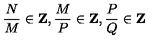

In [ ]:
dataset[0]['image']

In [ ]:
dataset[0]['text']

'{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'

In [ ]:
instruction = "Write the LaTeX representation for this image."

In [ ]:
def convert_to_conversation(sample):
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": instruction},
                    {"type": "image", "image": sample["image"]}
                ]
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": sample["text"]}
                ]
            }
        ]
    }

In [ ]:
dataset = dataset.map(convert_to_conversation)

Map:   0%|          | 0/68686 [00:00<?, ? examples/s]

In [ ]:
print(dataset[0])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40 at 0x7E0C4DBD63F0>, 'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }', 'messages': [{'content': [{'image': None, 'text': 'Write the LaTeX representation for this image.', 'type': 'text'}, {'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\xa0\x00\x00\x00(\x08\x02\x00\x00\x00\xf6Nf\xcf\x00\x00\x0b\x8cIDATx\x9c\xed[kl\x14\xd5\x17?\xf3\xd8\x9d\x99\xddm\xa7\xd2F\x14\xad\xc2\x07\x8c!\xa0\xec\x07\xb4E\x8aZ$V\xd3\xda\xe2\xa3iH\x90\x18E\xb1\x10\xa1K+"\x01i!\x9a(\xa5\xfa\xc1\x0f\x14\xc5\xf8\xc0`\xe2\xb2\x8b\xad\xd6D]\xb4\xb8\xeb\xb3\xd6DM\x0c\xb4\x15Lc\x8d)\xdb\xees\xde\xf7\xfe?\xdct,\xfb\x10h\xbb\xb3\xfd\x13~\x1f\x9a\xf6\xce\xec\xcco\xcf\xe3\x9es\xcf9\xa50\xc6p\x05\x97/\xd8l\x17L\xc5S\x14\x95\xb22y\xd1b\xa4\xb3\xba\x98K\x16 \xa3\x9f\xe4KJ\xe7q\xb8\xa0\x07#\x84h\x9a\xb6\x86\xcd\x941;I\xce\x06V\x99\x15\x8c\x10\xfa\xf3\xcf?\x05Ap

In [ ]:
convert_to_conversation(dataset[0])

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Write the LaTeX representation for this image.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=160x40>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '{ \\frac { N } { M } } \\in { \\bf Z } , { \\frac { M } { P } } \\in { \\bf Z } , { \\frac { P } { Q } } \\in { \\bf Z }'}]}]}

In [ ]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (model): Qwen2VLModel(
        (visual): Qwen2VisionTransformerPretrainedModel(
          (patch_embed): PatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-18): 19 x Qwen2VLVisionBlock(
              (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (attn): VisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1280, out_features=3840, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1280, out_features=16, bias=Fals

In [ ]:
image = dataset[1]["image"]

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": image}
        ]
    }
]

In [ ]:
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt=True)

In [ ]:
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt",
).to("cuda")

In [ ]:
from transformers import TextStreamer

text_streamer = TextStreamer(tokenizer, skip_prompt=True)

_ = model.generate(
    **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    use_cache=True,
    temperature=1.5,
    min_p=0.1
)

$$D _ { \mu } B \tilde { A } _ { \mu } ^ { B } = 0 ,$$<|im_end|>


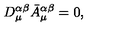

In [ ]:
image

In [26]:
FastVisionModel.for_inference(model)

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2VLForConditionalGeneration(
      (model): Qwen2VLModel(
        (visual): Qwen2VisionTransformerPretrainedModel(
          (patch_embed): PatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-18): 19 x Qwen2VLVisionBlock(
              (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
              (attn): VisionAttention(
                (qkv): lora.Linear(
                  (base_layer): Linear(in_features=1280, out_features=3840, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Identity()
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1280, out_features=16, bias=Fals

In [27]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bf16_supported
from unsloth.trainer import UnslothVisionDataCollator

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,

    data_collator=UnslothVisionDataCollator(model,tokenizer),

    train_dataset=dataset,   # use mapped dataset

    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        max_steps=100,   # increase later
        learning_rate=2e-4,

        fp16=not is_bf16_supported(),
        bf16=is_bf16_supported(),

        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",

        seed=3407,
        output_dir="outputs",

        report_to="none",
        remove_unused_columns=False,

        dataset_text_field="",
        dataset_kwargs={"skip_prepare_dataset": True},

        max_seq_length=2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [28]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 68,686 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 50,855,936 of 8,342,231,552 (0.61% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.178870
2,1.323116
3,1.397655
4,0.969512
5,0.888869
6,0.892133
7,0.703198
8,0.455280
9,0.297075
10,0.317189


Step,Training Loss
1,1.178870
2,1.323116
3,1.397655
4,0.969512
5,0.888869
6,0.892133
7,0.703198
8,0.455280
9,0.297075
10,0.317189


TrainOutput(global_step=100, training_loss=0.19573260575532914, metrics={'train_runtime': 707.4103, 'train_samples_per_second': 1.131, 'train_steps_per_second': 0.141, 'total_flos': 5338828618180608.0, 'train_loss': 0.19573260575532914})

In [31]:
# Step 1: Inference mode
model = FastVisionModel.for_inference(model)

# Step 2: Get image
image = dataset[10]["image"]

# Step 3: Instruction
instruction = "Write the LaTeX representation for this image."

# Step 4: Create messages (FIXED)
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": instruction},
            {"type": "image", "image": image}
        ]
    }
]

# Step 5: Convert chat → text
input_text = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True
)

# Step 6: Create inputs (image + text)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens=False,
    return_tensors="pt"
).to("cuda")

# Step 7: Streaming output
from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt=True)

# Step 8: Generate output
_ = model.generate(
    **inputs,
    streamer=text_streamer,
    max_new_tokens=128,
    temperature=0.2,   # IMPORTANT (low for accuracy)
    use_cache=True
)

\left[ \left[ B _ { n } ^ { + } , b _ { n } ^ { + } \right] , b _ { n } ^ { + } \right] = n B _ { n } ^ { + } , \quad \left[ \left[ B _ { n } ^ { + } , b _ { n } ^ { + } \right] , b _ { n } ^ { - } \right] = n B _ { n } ^ { - } .<|im_end|>


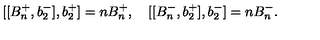

In [32]:
image